In [3]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "evaluate.py").exists():
    ROOT = ROOT / "CSE-599-Project"

TEST_CORPUS = ROOT / "data/c4_103/test.jsonl"
TOKENIZER_PATTERN = "huggingface_tokenizers_16k_c4_*"
FAMILIES = ["bpe", "unigram", "wordpiece", "wordlevel"]
COLORS = {"bpe": "C0", "unigram": "C1", "wordpiece": "C2", "wordlevel": "C3"}
MARKERS = {"bpe": "o", "unigram": "s", "wordpiece": "^", "wordlevel": "D"}

In [4]:
def train_chars_for_scale(scale: str) -> int | None:
    train_path = ROOT / f"data/c4_{scale}/train.jsonl"
    if not train_path.exists():
        return None
    return sum(len(json.loads(line)["text"]) for line in train_path.open(encoding="utf-8"))


def ensure_summary(tokenizer_dir: Path, test_path: Path) -> Path:
    scale = tokenizer_dir.name.rsplit("_c4_", 1)[-1]
    result_dir = ROOT / "results" / f"c4_{scale}_test"
    summary_path = result_dir / "summary.json"
    if summary_path.exists():
        return summary_path

    from evaluate import discover_tokenizer_paths, evaluate_tokenizer, load_jsonl_texts

    texts = load_jsonl_texts(test_path)
    summary = {"test_corpus": str(test_path), "tokenizers": {}}
    for family, tok_path in discover_tokenizer_paths(tokenizer_dir).items():
        summary["tokenizers"][family] = evaluate_tokenizer(tok_path, texts)
    result_dir.mkdir(parents=True, exist_ok=True)
    summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
    return summary_path


def load_metrics_df() -> pd.DataFrame:
    rows: list[dict] = []
    tokenizer_dirs = sorted((ROOT / "tokenizer_ckpts").glob(TOKENIZER_PATTERN))
    if not tokenizer_dirs:
        raise FileNotFoundError(f"No tokenizers under tokenizer_ckpts/{TOKENIZER_PATTERN}")

    for tokenizer_dir in tokenizer_dirs:
        scale = tokenizer_dir.name.rsplit("_c4_", 1)[-1]
        summary_path = ensure_summary(tokenizer_dir, TEST_CORPUS)
        summary = json.loads(summary_path.read_text(encoding="utf-8"))
        train_chars = train_chars_for_scale(scale)

        for family, metrics in summary["tokenizers"].items():
            row = {
                "scale": scale,
                "train_chars": train_chars,
                "family": family,
                "compression_ratio": metrics["compression_ratio"],
            }
            for key, value in metrics["entropies_bits_per_token"].items():
                row[f"entropy_{key}"] = value
            for key, value in metrics["entropy_rates_bits_per_char"].items():
                row[f"rate_{key}"] = value
            rows.append(row)

    df = pd.DataFrame(rows)
    df["family"] = pd.Categorical(df["family"], categories=FAMILIES, ordered=True)
    return df.sort_values(["scale", "family"]).reset_index(drop=True)


def use_log_train_axis(df: pd.DataFrame) -> bool:
    """Use log train_chars on x only when every scale has a train.jsonl char count."""
    by_scale = df.groupby("scale", observed=True)["train_chars"].first()
    return bool(by_scale.notna().all() and by_scale.nunique() > 1)


df = load_metrics_df()
LOG_X = use_log_train_axis(df)
df

,scale,train_chars,family,compression_ratio,entropy_H1,entropy_H2,entropy_H3,entropy_H4,entropy_H5,rate_H1,rate_H2,rate_H3,rate_H4,rate_H5
0,103,1654070.0,bpe,4.475979,10.122557,4.259017,0.918518,0.172586,0.057012,2.272215,0.956023,0.206180,0.038740,0.012797
1,103,1654070.0,unigram,3.850028,9.220746,4.686223,1.420006,0.310424,0.087546,2.406297,1.222943,0.370573,0.081010,0.022847
2,103,1654070.0,wordpiece,4.412332,10.221874,4.162561,0.934506,0.174911,0.056342,2.327606,0.947850,0.212795,0.039829,0.012830
3,103,1654070.0,wordlevel,5.153920,9.015170,4.520741,1.407413,0.319838,0.075486,1.757451,0.881290,0.274366,0.062350,0.014715
4,104,NaN,bpe,4.585394,10.145512,4.243349,0.910687,0.160491,0.048873,2.223025,0.929778,0.199544,0.035166,0.010709
5,104,NaN,unigram,4.175259,9.349774,4.680351,1.290504,0.243477,0.066978,2.249909,1.126269,0.310544,0.058590,0.016117
6,104,NaN,wordpiece,4.478928,10.223150,4.166502,0.926477,0.168943,0.053802,2.293284,0.934641,0.207830,0.037898,0.012069
7,104,NaN,wordlevel,5.153920,9.317426,4.463037,1.255905,0.249552,0.058789,1.816374,0.870041,0.244831,0.048649,0.011461
8,105,NaN,bpe,4.472855,10.131691,4.263061,0.916083,0.167871,0.055298,2.275853,0.957599,0.205777,0.037708,0.012421
9,105,NaN,unigram,4.148621,9.313341,4.667680,1.287434,0.267146,0.080133,2.255531,1.130432,0.311794,0.064698,0.019407


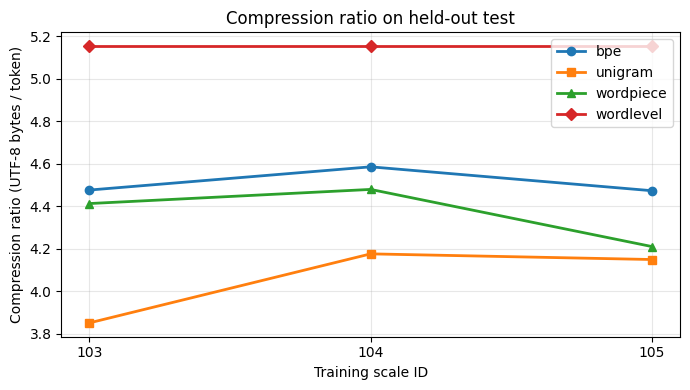

In [5]:
def _x_label() -> str:
    return "Training chars (log scale)" if LOG_X else "Training scale ID"


def _plot_x(sub: pd.DataFrame):
    return sub["train_chars"] if LOG_X else sub["scale"].astype(str)


def plot_compression_ratio(df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(7, 4))
    n_scales = df["scale"].nunique()

    if n_scales > 1:
        for family in FAMILIES:
            sub = df[df["family"] == family].sort_values("scale")
            ax.plot(
                _plot_x(sub), sub["compression_ratio"],
                marker=MARKERS[family], color=COLORS[family], label=family, linewidth=2,
            )
        if LOG_X:
            ax.set_xscale("log")
        ax.set_xlabel(_x_label())
    else:
        sub = df.sort_values("family")
        ax.bar(sub["family"].astype(str), sub["compression_ratio"], color=[COLORS[f] for f in sub["family"]])
        ax.set_xlabel("Tokenizer family")

    ax.set_ylabel("Compression ratio (UTF-8 bytes / token)")
    ax.set_title("Compression ratio on held-out test")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()


plot_compression_ratio(df)
plt.show()

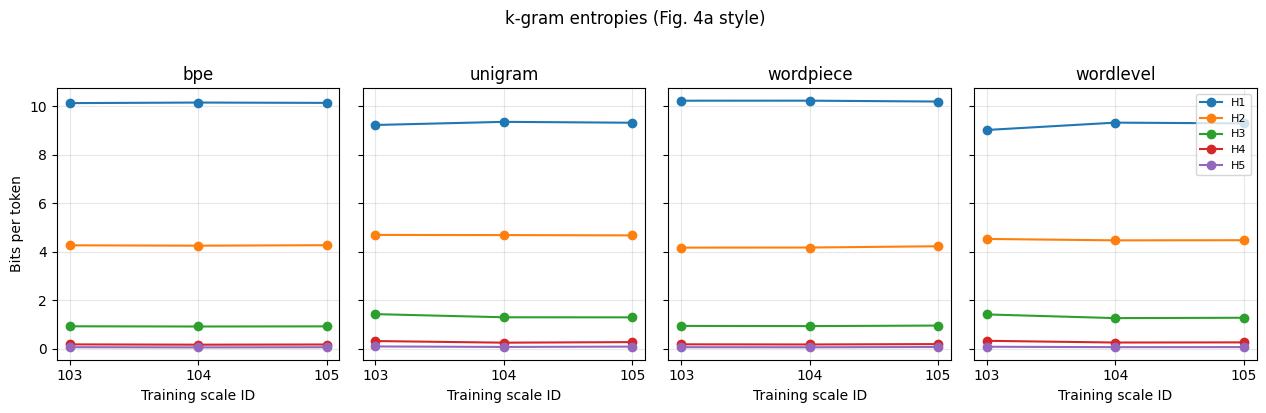

In [6]:
def plot_kgram_entropies(df: pd.DataFrame) -> None:
    entropy_cols = [c for c in df.columns if c.startswith("entropy_H")]
    orders = sorted(entropy_cols, key=lambda c: int(re.search(r"H(\d+)", c).group(1)))
    n_scales = df["scale"].nunique()

    if n_scales > 1:
        fig, axes = plt.subplots(1, len(FAMILIES), figsize=(3.2 * len(FAMILIES), 4), sharey=True)
        if len(FAMILIES) == 1:
            axes = [axes]
        for ax, family in zip(axes, FAMILIES):
            sub = df[df["family"] == family].sort_values("scale")
            for col in orders:
                k = col.replace("entropy_H", "")
                ax.plot(_plot_x(sub), sub[col], marker="o", label=f"H{k}")
            if LOG_X:
                ax.set_xscale("log")
            ax.set_title(family)
            ax.set_xlabel(_x_label())
            ax.grid(True, alpha=0.3)
        axes[0].set_ylabel("Bits per token")
        axes[-1].legend(loc="upper right", fontsize=8)
        fig.suptitle("k-gram entropies (Fig. 4a style)", y=1.02)
    else:
        fig, ax = plt.subplots(figsize=(8, 4))
        x = range(len(FAMILIES))
        width = 0.15
        for i, col in enumerate(orders):
            vals = [df.loc[df["family"] == f, col].iloc[0] for f in FAMILIES]
            ax.bar([p + i * width for p in x], vals, width=width, label=col.replace("entropy_", ""))
        ax.set_xticks([p + width * (len(orders) - 1) / 2 for p in x])
        ax.set_xticklabels(FAMILIES)
        ax.set_ylabel("Bits per token")
        ax.set_title("k-gram entropies by tokenizer family")
        ax.legend()
        ax.grid(True, alpha=0.3, axis="y")
    fig.tight_layout()


plot_kgram_entropies(df)
plt.show()

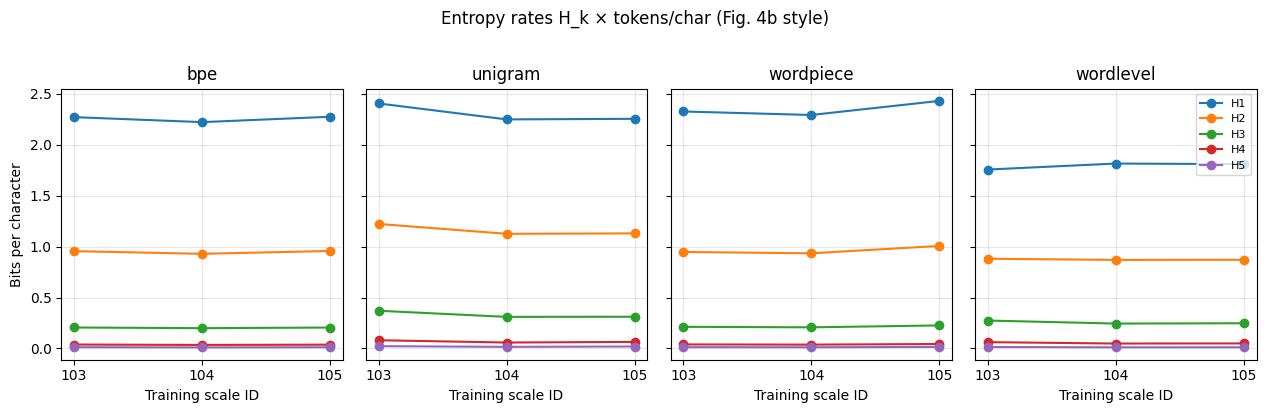

In [7]:
def plot_entropy_rates(df: pd.DataFrame) -> None:
    rate_cols = [c for c in df.columns if c.startswith("rate_H")]
    orders = sorted(rate_cols, key=lambda c: int(re.search(r"H(\d+)", c).group(1)))
    n_scales = df["scale"].nunique()

    if n_scales > 1:
        fig, axes = plt.subplots(1, len(FAMILIES), figsize=(3.2 * len(FAMILIES), 4), sharey=True)
        if len(FAMILIES) == 1:
            axes = [axes]
        for ax, family in zip(axes, FAMILIES):
            sub = df[df["family"] == family].sort_values("scale")
            for col in orders:
                k = col.replace("rate_H", "")
                ax.plot(_plot_x(sub), sub[col], marker="o", label=f"H{k}")
            if LOG_X:
                ax.set_xscale("log")
            ax.set_title(family)
            ax.set_xlabel(_x_label())
            ax.grid(True, alpha=0.3)
        axes[0].set_ylabel("Bits per character")
        axes[-1].legend(loc="upper right", fontsize=8)
        fig.suptitle("Entropy rates H_k × tokens/char (Fig. 4b style)", y=1.02)
    else:
        fig, ax = plt.subplots(figsize=(8, 4))
        x = range(len(FAMILIES))
        width = 0.15
        for i, col in enumerate(orders):
            vals = [df.loc[df["family"] == f, col].iloc[0] for f in FAMILIES]
            ax.bar([p + i * width for p in x], vals, width=width, label=col.replace("rate_", ""))
        ax.set_xticks([p + width * (len(orders) - 1) / 2 for p in x])
        ax.set_xticklabels(FAMILIES)
        ax.set_ylabel("Bits per character")
        ax.set_title("Entropy rates by tokenizer family")
        ax.legend()
        ax.grid(True, alpha=0.3, axis="y")
    fig.tight_layout()


plot_entropy_rates(df)
plt.show()